In [ ]:
from google.colab import files

uploaded = files.upload()

Saving lapiz_group_brd_aligned.xlsx to lapiz_group_brd_aligned.xlsx


In [ ]:
!pip install rapidfuzz openpyxl -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 41.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import re
from rapidfuzz import fuzz
import matplotlib.pyplot as plt

In [ ]:
file_name = "lapiz_group_brd_aligned.xlsx"

excel_file = pd.ExcelFile(file_name)

print("Sheets in workbook:")
for sheet in excel_file.sheet_names:
    print("-", sheet)

Sheets in workbook:
- README
- dim_organization
- dim_branch
- dim_team
- dim_salesperson_master
- dim_salesperson
- dim_customer_master
- dim_customer
- dim_brand
- dim_item
- dim_vendor
- dim_account
- fact_invoice
- fact_invoice_line
- fact_payment
- fact_payment_applied
- fact_credit_note
- fact_bill
- fact_purchase_order
- fact_purchase_order_line
- fact_inventory_stock
- fact_gl
- dim_bank_account
- cfg_target
- ml_duplicate_training_pairs
- anomaly_metric_timeseries
- ml_anomaly_labels
- Dashboard_Summary
- Data_Dictionary


In [ ]:
dim_organization = pd.read_excel(file_name, sheet_name="dim_organization")
dim_branch = pd.read_excel(file_name, sheet_name="dim_branch")
dim_team = pd.read_excel(file_name, sheet_name="dim_team")
dim_salesperson_master = pd.read_excel(file_name, sheet_name="dim_salesperson_master")
dim_salesperson = pd.read_excel(file_name, sheet_name="dim_salesperson")
dim_customer_master = pd.read_excel(file_name, sheet_name="dim_customer_master")
dim_customer = pd.read_excel(file_name, sheet_name="dim_customer")
dim_brand = pd.read_excel(file_name, sheet_name="dim_brand")
dim_item = pd.read_excel(file_name, sheet_name="dim_item")
dim_vendor = pd.read_excel(file_name, sheet_name="dim_vendor")
dim_account = pd.read_excel(file_name, sheet_name="dim_account")

fact_invoice = pd.read_excel(file_name, sheet_name="fact_invoice")
fact_invoice_line = pd.read_excel(file_name, sheet_name="fact_invoice_line")
fact_payment = pd.read_excel(file_name, sheet_name="fact_payment")
fact_payment_applied = pd.read_excel(file_name, sheet_name="fact_payment_applied")
fact_credit_note = pd.read_excel(file_name, sheet_name="fact_credit_note")
fact_bill = pd.read_excel(file_name, sheet_name="fact_bill")
fact_purchase_order = pd.read_excel(file_name, sheet_name="fact_purchase_order")
fact_purchase_order_line = pd.read_excel(file_name, sheet_name="fact_purchase_order_line")
fact_inventory_stock = pd.read_excel(file_name, sheet_name="fact_inventory_stock")
fact_gl = pd.read_excel(file_name, sheet_name="fact_gl")
dim_bank_account = pd.read_excel(file_name, sheet_name="dim_bank_account")
cfg_target = pd.read_excel(file_name, sheet_name="cfg_target")

ml_duplicate_training_pairs = pd.read_excel(file_name, sheet_name="ml_duplicate_training_pairs")
anomaly_metric_timeseries = pd.read_excel(file_name, sheet_name="anomaly_metric_timeseries")
ml_anomaly_labels = pd.read_excel(file_name, sheet_name="ml_anomaly_labels")

data_dictionary = pd.read_excel(file_name, sheet_name="Data_Dictionary")

In [ ]:
print("Organizations:")
display(dim_organization.head())

print("Customers:")
display(dim_customer.head())

print("Invoices:")
display(fact_invoice.head())

print("Duplicate Training Pairs:")
display(ml_duplicate_training_pairs.head())

print("Anomaly Timeseries:")
display(anomaly_metric_timeseries.head())

Organizations:


,organization_id,entity_name,base_currency,is_lapiz,active
0,719219457,Lapiz Blue DXB/SHJ,AED,True,True
1,791250515,Lapiz Blue Abu Dhabi,AED,True,True
2,903438347,Global Classic (GCB),AED,False,True
3,855049662,60 Newton,AED,False,True


Customers:


,customer_id,organization_id,customer_name,customer_master_id,payment_terms,credit_limit,phone,trn
0,CUST-0001,791250515,Al-Noor Contracting L.L.C,CM001,90,100000,520001001,100230001
1,CUST-0002,903438347,Al-Noor Contracting L.L.C,CM001,90,100000,520007779,100230001
2,CUST-0003,855049662,Bluestar Interior LLC,CM002,60,50000,520010139,100230002
3,CUST-0004,719219457,Bluestar Interior LLC,CM002,30,75000,520004793,100230002
4,CUST-0005,719219457,Emirates Buildtech LLC,CM003,45,50000,520003554,100230003


Invoices:


,invoice_id,organization_id,branch_id,customer_id,salesperson_id,invoice_date,status,sub_total,tax_total,total,balance_due
0,INV-00001,719219457,BR-DXB,CUST-0032,SP-457-03,45665,sent,2262.70,113.13,2375.83,2375.83
1,INV-00002,719219457,BR-DXB,CUST-0022,SP-457-03,45665,paid,4761.89,238.09,4999.98,0.00
2,INV-00003,719219457,BR-SHJ,CUST-0011,SP-457-03,45679,overdue,2692.17,134.61,2826.78,1888.94
3,INV-00004,719219457,BR-SHJ,CUST-0020,SP-457-05,45665,paid,1277.29,63.86,1341.15,0.00
4,INV-00005,719219457,BR-DXB,CUST-0022,SP-457-01,45662,paid,2326.39,116.32,2442.71,0.00


Duplicate Training Pairs:


,pair_id,customer_id_a,customer_id_b,similarity_score,status,is_duplicate,notes
0,DUP-0001,CUST-0001,CUST-0002,0.949,candidate,1,Same master customer; typo/cross-org duplicate
1,DUP-0002,CUST-0003,CUST-0004,0.981,candidate,1,Same master customer; typo/cross-org duplicate
2,DUP-0003,CUST-0005,CUST-0006,0.976,candidate,1,Same master customer; typo/cross-org duplicate
3,DUP-0004,CUST-0005,CUST-0007,0.927,candidate,1,Same master customer; typo/cross-org duplicate
4,DUP-0005,CUST-0005,CUST-0008,0.958,candidate,1,Same master customer; typo/cross-org duplicate


Anomaly Timeseries:


,period,organization_id,branch_id,brand_id,salesperson_master_id,metric_name,actual_value,is_anomaly_label
0,45658,719219457,NaN,NaN,NaN,sales_aed,41223.7800,0
1,45658,719219457,NaN,NaN,NaN,collections_aed,12578.4700,0
2,45658,719219457,NaN,NaN,NaN,gross_margin_pct,0.3546,0
3,45689,719219457,NaN,NaN,NaN,sales_aed,90218.6400,0
4,45689,719219457,NaN,NaN,NaN,collections_aed,35317.4200,0


In [ ]:
def clean_column_names(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("-", "_")
    )
    return df

all_tables = [
    dim_organization, dim_branch, dim_team, dim_salesperson_master,
    dim_salesperson, dim_customer_master, dim_customer, dim_brand,
    dim_item, dim_vendor, dim_account, fact_invoice, fact_invoice_line,
    fact_payment, fact_payment_applied, fact_credit_note, fact_bill,
    fact_purchase_order, fact_purchase_order_line, fact_inventory_stock,
    fact_gl, dim_bank_account, cfg_target, ml_duplicate_training_pairs,
    anomaly_metric_timeseries, ml_anomaly_labels, data_dictionary
]

for table in all_tables:
    clean_column_names(table)

print("Column names cleaned.")

Column names cleaned.


In [ ]:
id_columns = [
    "organization_id", "branch_id", "team_id", "salesperson_master_id",
    "salesperson_id", "customer_master_id", "customer_id", "brand_id",
    "item_id", "vendor_id", "account_id", "invoice_id", "line_id",
    "payment_id", "creditnote_id", "bill_id", "purchase_order_id",
    "bank_account_id", "target_id", "pair_id", "anomaly_id"
]

def convert_id_columns_to_text(df):
    for col in df.columns:
        if col in id_columns or col.endswith("_id"):
            df[col] = df[col].astype(str)
            df[col] = df[col].replace("nan", np.nan)
    return df

for table in all_tables:
    convert_id_columns_to_text(table)

print("ID columns converted to text.")

ID columns converted to text.


/tmp/ipykernel_9827/2543724966.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace("nan", np.nan)
/tmp/ipykernel_9827/2543724966.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace("nan", np.nan)
/tmp/ipykernel_9827/2543724966.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_

In [ ]:
id_columns = [
    "organization_id", "branch_id", "team_id", "salesperson_master_id",
    "salesperson_id", "customer_master_id", "customer_id", "brand_id",
    "item_id", "vendor_id", "account_id", "invoice_id", "line_id",
    "payment_id", "creditnote_id", "bill_id", "purchase_order_id",
    "bank_account_id", "target_id", "pair_id", "anomaly_id"
]

def convert_id_columns_to_text(df):
    for col in df.columns:
        if col in id_columns or col.endswith("_id"):
            df[col] = df[col].astype(str)
            df[col] = df[col].replace("nan", np.nan)
    return df

for table in all_tables:
    convert_id_columns_to_text(table)

print("ID columns converted to text.")

ID columns converted to text.


/tmp/ipykernel_9827/2543724966.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace("nan", np.nan)
/tmp/ipykernel_9827/2543724966.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace("nan", np.nan)
/tmp/ipykernel_9827/2543724966.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_

In [ ]:
display(fact_invoice[["invoice_id", "invoice_date"]].head())
display(anomaly_metric_timeseries[["period", "metric_name", "actual_value"]].head())

,invoice_id,invoice_date
0,INV-00001,45665
1,INV-00002,45665
2,INV-00003,45679
3,INV-00004,45665
4,INV-00005,45662


,period,metric_name,actual_value
0,45658,sales_aed,41223.7800
1,45658,collections_aed,12578.4700
2,45658,gross_margin_pct,0.3546
3,45689,sales_aed,90218.6400
4,45689,collections_aed,35317.4200


In [ ]:
def missing_report(df, name):
    print(f"Missing values in {name}:")
    missing = df.isnull().sum()
    print(missing[missing > 0])

missing_report(dim_customer, "dim_customer")
missing_report(fact_invoice, "fact_invoice")
missing_report(fact_invoice_line, "fact_invoice_line")
missing_report(anomaly_metric_timeseries, "anomaly_metric_timeseries")

Missing values in dim_customer:
Series([], dtype: int64)
Missing values in fact_invoice:
salesperson_id    44
dtype: int64
Missing values in fact_invoice_line:
brand_id    545
dtype: int64
Missing values in anomaly_metric_timeseries:
branch_id                216
brand_id                 216
salesperson_master_id    216
dtype: int64


In [ ]:
print("Duplicate invoice IDs:", fact_invoice["invoice_id"].duplicated().sum())
print("Duplicate customer IDs:", dim_customer["customer_id"].duplicated().sum())
print("Duplicate item IDs:", dim_item["item_id"].duplicated().sum())

Duplicate invoice IDs: 0
Duplicate customer IDs: 0
Duplicate item IDs: 0


In [ ]:
def clean_customer_name(name):
    if pd.isna(name):
        return ""

    name = str(name).lower()

    # Remove punctuation
    name = re.sub(r"[^a-z0-9\s]", " ", name)

    # Remove common company words
    remove_words = [
        "llc", "l l c", "ltd", "limited", "company", "co",
        "trading", "general", "contracting", "est", "establishment",
        "building", "materials"
    ]

    for word in remove_words:
        name = re.sub(r"\b" + re.escape(word) + r"\b", " ", name)

    # Remove extra spaces
    name = re.sub(r"\s+", " ", name).strip()

    return name

dim_customer["cleaned_customer_name"] = dim_customer["customer_name"].apply(clean_customer_name)

display(dim_customer[["customer_id", "customer_name", "cleaned_customer_name", "phone", "trn"]].head(10))

,customer_id,customer_name,cleaned_customer_name,phone,trn
0,CUST-0001,Al-Noor Contracting L.L.C,al noor,520001001,100230001
1,CUST-0002,Al-Noor Contracting L.L.C,al noor,520007779,100230001
2,CUST-0003,Bluestar Interior LLC,bluestar interior,520010139,100230002
3,CUST-0004,Bluestar Interior LLC,bluestar interior,520004793,100230002
4,CUST-0005,Emirates Buildtech LLC,emirates buildtech,520003554,100230003
5,CUST-0006,Emirates Buildtech LLC,emirates buildtech,520001811,100230003
6,CUST-0007,Emirates Build Tech,emirates build tech,520006760,100230003
7,CUST-0008,Emirates Build Tech,emirates build tech,520003674,100230003
8,CUST-0009,Royal Palace Projects,royal palace projects,520007077,100230004
9,CUST-0010,Royal Palace Projects,royal palace projects,520000722,100230004


In [ ]:
customers_a = dim_customer.add_suffix("_a")
customers_b = dim_customer.add_suffix("_b")

duplicate_dataset = ml_duplicate_training_pairs.merge(
    customers_a,
    left_on="customer_id_a",
    right_on="customer_id_a",
    how="left"
)

duplicate_dataset = duplicate_dataset.merge(
    customers_b,
    left_on="customer_id_b",
    right_on="customer_id_b",
    how="left"
)

display(duplicate_dataset.head())

,pair_id,customer_id_a,customer_id_b,similarity_score,status,is_duplicate,notes,organization_id_a,customer_name_a,customer_master_id_a,...,trn_a,cleaned_customer_name_a,organization_id_b,customer_name_b,customer_master_id_b,payment_terms_b,credit_limit_b,phone_b,trn_b,cleaned_customer_name_b
0,DUP-0001,CUST-0001,CUST-0002,0.949,candidate,1,Same master customer; typo/cross-org duplicate,791250515,Al-Noor Contracting L.L.C,CM001,...,100230001,al noor,903438347,Al-Noor Contracting L.L.C,CM001,90,100000,520007779,100230001,al noor
1,DUP-0002,CUST-0003,CUST-0004,0.981,candidate,1,Same master customer; typo/cross-org duplicate,855049662,Bluestar Interior LLC,CM002,...,100230002,bluestar interior,719219457,Bluestar Interior LLC,CM002,30,75000,520004793,100230002,bluestar interior
2,DUP-0003,CUST-0005,CUST-0006,0.976,candidate,1,Same master customer; typo/cross-org duplicate,719219457,Emirates Buildtech LLC,CM003,...,100230003,emirates buildtech,855049662,Emirates Buildtech LLC,CM003,90,150000,520001811,100230003,emirates buildtech
3,DUP-0004,CUST-0005,CUST-0007,0.927,candidate,1,Same master customer; typo/cross-org duplicate,719219457,Emirates Buildtech LLC,CM003,...,100230003,emirates buildtech,903438347,Emirates Build Tech,CM003,60,100000,520006760,100230003,emirates build tech
4,DUP-0005,CUST-0005,CUST-0008,0.958,candidate,1,Same master customer; typo/cross-org duplicate,719219457,Emirates Buildtech LLC,CM003,...,100230003,emirates buildtech,791250515,Emirates Build Tech,CM003,90,250000,520003674,100230003,emirates build tech


In [ ]:
def safe_fuzzy_score(a, b):
    if pd.isna(a) or pd.isna(b):
        return 0
    return fuzz.token_sort_ratio(str(a), str(b)) / 100

duplicate_dataset["raw_name_similarity"] = duplicate_dataset.apply(
    lambda row: safe_fuzzy_score(row["customer_name_a"], row["customer_name_b"]),
    axis=1
)

duplicate_dataset["cleaned_name_similarity"] = duplicate_dataset.apply(
    lambda row: safe_fuzzy_score(row["cleaned_customer_name_a"], row["cleaned_customer_name_b"]),
    axis=1
)

duplicate_dataset["same_trn"] = np.where(
    (duplicate_dataset["trn_a"].notna()) &
    (duplicate_dataset["trn_b"].notna()) &
    (duplicate_dataset["trn_a"] == duplicate_dataset["trn_b"]),
    1,
    0
)

duplicate_dataset["same_phone"] = np.where(
    (duplicate_dataset["phone_a"].notna()) &
    (duplicate_dataset["phone_b"].notna()) &
    (duplicate_dataset["phone_a"] == duplicate_dataset["phone_b"]),
    1,
    0
)

duplicate_dataset["same_organization"] = np.where(
    duplicate_dataset["organization_id_a"] == duplicate_dataset["organization_id_b"],
    1,
    0
)

duplicate_dataset["same_customer_master"] = np.where(
    duplicate_dataset["customer_master_id_a"] == duplicate_dataset["customer_master_id_b"],
    1,
    0
)

display(duplicate_dataset[[
    "pair_id",
    "customer_id_a",
    "customer_name_a",
    "customer_id_b",
    "customer_name_b",
    "raw_name_similarity",
    "cleaned_name_similarity",
    "same_trn",
    "same_phone",
    "same_organization",
    "is_duplicate"
]].head(10))

,pair_id,customer_id_a,customer_name_a,customer_id_b,customer_name_b,raw_name_similarity,cleaned_name_similarity,same_trn,same_phone,same_organization,is_duplicate
0,DUP-0001,CUST-0001,Al-Noor Contracting L.L.C,CUST-0002,Al-Noor Contracting L.L.C,1.000000,1.000000,1,0,0,1
1,DUP-0002,CUST-0003,Bluestar Interior LLC,CUST-0004,Bluestar Interior LLC,1.000000,1.000000,1,0,0,1
2,DUP-0003,CUST-0005,Emirates Buildtech LLC,CUST-0006,Emirates Buildtech LLC,1.000000,1.000000,1,0,0,1
3,DUP-0004,CUST-0005,Emirates Buildtech LLC,CUST-0007,Emirates Build Tech,0.731707,0.756757,1,0,0,1
4,DUP-0005,CUST-0005,Emirates Buildtech LLC,CUST-0008,Emirates Build Tech,0.731707,0.756757,1,0,0,1
5,DUP-0006,CUST-0006,Emirates Buildtech LLC,CUST-0007,Emirates Build Tech,0.731707,0.756757,1,0,0,1
6,DUP-0007,CUST-0006,Emirates Buildtech LLC,CUST-0008,Emirates Build Tech,0.731707,0.756757,1,0,0,1
7,DUP-0008,CUST-0007,Emirates Build Tech,CUST-0008,Emirates Build Tech,1.000000,1.000000,1,0,0,1
8,DUP-0009,CUST-0009,Royal Palace Projects,CUST-0010,Royal Palace Projects,1.000000,1.000000,1,0,0,1
9,DUP-0010,CUST-0009,Royal Palace Projects,CUST-0011,Royal Palace Projects,1.000000,1.000000,1,0,0,1


In [ ]:
person4_duplicate_dataset = duplicate_dataset[[
    "pair_id",
    "customer_id_a",
    "customer_name_a",
    "cleaned_customer_name_a",
    "organization_id_a",
    "phone_a",
    "trn_a",
    "customer_id_b",
    "customer_name_b",
    "cleaned_customer_name_b",
    "organization_id_b",
    "phone_b",
    "trn_b",
    "raw_name_similarity",
    "cleaned_name_similarity",
    "same_trn",
    "same_phone",
    "same_organization",
    "same_customer_master",
    "is_duplicate"
]].copy()

display(person4_duplicate_dataset.head())

,pair_id,customer_id_a,customer_name_a,cleaned_customer_name_a,organization_id_a,phone_a,trn_a,customer_id_b,customer_name_b,cleaned_customer_name_b,organization_id_b,phone_b,trn_b,raw_name_similarity,cleaned_name_similarity,same_trn,same_phone,same_organization,same_customer_master,is_duplicate
0,DUP-0001,CUST-0001,Al-Noor Contracting L.L.C,al noor,791250515,520001001,100230001,CUST-0002,Al-Noor Contracting L.L.C,al noor,903438347,520007779,100230001,1.000000,1.000000,1,0,0,1,1
1,DUP-0002,CUST-0003,Bluestar Interior LLC,bluestar interior,855049662,520010139,100230002,CUST-0004,Bluestar Interior LLC,bluestar interior,719219457,520004793,100230002,1.000000,1.000000,1,0,0,1,1
2,DUP-0003,CUST-0005,Emirates Buildtech LLC,emirates buildtech,719219457,520003554,100230003,CUST-0006,Emirates Buildtech LLC,emirates buildtech,855049662,520001811,100230003,1.000000,1.000000,1,0,0,1,1
3,DUP-0004,CUST-0005,Emirates Buildtech LLC,emirates buildtech,719219457,520003554,100230003,CUST-0007,Emirates Build Tech,emirates build tech,903438347,520006760,100230003,0.731707,0.756757,1,0,0,1,1
4,DUP-0005,CUST-0005,Emirates Buildtech LLC,emirates buildtech,719219457,520003554,100230003,CUST-0008,Emirates Build Tech,emirates build tech,791250515,520003674,100230003,0.731707,0.756757,1,0,0,1,1


In [ ]:
person4_duplicate_dataset.to_csv("person4_duplicate_customer_dataset.csv", index=False)

print("Person 4 duplicate customer dataset saved.")

Person 4 duplicate customer dataset saved.


In [ ]:
anomaly_data = anomaly_metric_timeseries.copy()

# Fill missing scope fields with ALL
scope_cols = ["organization_id", "branch_id", "brand_id", "salesperson_master_id"]

for col in scope_cols:
    anomaly_data[col] = anomaly_data[col].fillna("ALL").astype(str)

anomaly_data["metric_name"] = anomaly_data["metric_name"].astype(str)
anomaly_data["actual_value"] = pd.to_numeric(anomaly_data["actual_value"], errors="coerce")

anomaly_data = anomaly_data.sort_values(
    by=["organization_id", "branch_id", "brand_id", "salesperson_master_id", "metric_name", "period"]
).reset_index(drop=True)

display(anomaly_data.head())

,period,organization_id,branch_id,brand_id,salesperson_master_id,metric_name,actual_value,is_anomaly_label
0,45658,719219457,ALL,ALL,ALL,collections_aed,12578.47,0
1,45689,719219457,ALL,ALL,ALL,collections_aed,35317.42,0
2,45717,719219457,ALL,ALL,ALL,collections_aed,23880.89,0
3,45748,719219457,ALL,ALL,ALL,collections_aed,25724.36,0
4,45778,719219457,ALL,ALL,ALL,collections_aed,30625.66,0


In [ ]:
group_cols = ["organization_id", "branch_id", "brand_id", "salesperson_master_id", "metric_name"]

anomaly_data["previous_value"] = anomaly_data.groupby(group_cols)["actual_value"].shift(1)

anomaly_data["rolling_mean_3"] = anomaly_data.groupby(group_cols)["actual_value"].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
)

anomaly_data["rolling_std_3"] = anomaly_data.groupby(group_cols)["actual_value"].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).std()
)

anomaly_data["rolling_mean_6"] = anomaly_data.groupby(group_cols)["actual_value"].transform(
    lambda x: x.shift(1).rolling(window=6, min_periods=1).mean()
)

anomaly_data["rolling_std_6"] = anomaly_data.groupby(group_cols)["actual_value"].transform(
    lambda x: x.shift(1).rolling(window=6, min_periods=1).std()
)

display(anomaly_data.head(10))

,period,organization_id,branch_id,brand_id,salesperson_master_id,metric_name,actual_value,is_anomaly_label,previous_value,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6
0,45658,719219457,ALL,ALL,ALL,collections_aed,12578.47,0,NaN,NaN,NaN,NaN,NaN
1,45689,719219457,ALL,ALL,ALL,collections_aed,35317.42,0,12578.47,12578.470000,NaN,12578.470000,NaN
2,45717,719219457,ALL,ALL,ALL,collections_aed,23880.89,0,35317.42,23947.945000,16078.865742,23947.945000,16078.865742
3,45748,719219457,ALL,ALL,ALL,collections_aed,25724.36,0,23880.89,23925.593333,11369.540913,23925.593333,11369.540913
4,45778,719219457,ALL,ALL,ALL,collections_aed,30625.66,0,25724.36,28307.556667,6140.295870,24375.285000,9326.656998
5,45809,719219457,ALL,ALL,ALL,collections_aed,47985.97,0,30625.66,26743.636667,3485.996885,25625.360000,8547.124405
6,45839,719219457,ALL,ALL,ALL,collections_aed,33997.03,0,47985.97,34778.663333,11697.452606,29352.128333,11906.950984
7,45870,719219457,ALL,ALL,ALL,collections_aed,34252.77,0,33997.03,37536.220000,9205.405489,32921.888333,8632.934467
8,45901,719219457,ALL,ALL,ALL,collections_aed,37740.49,0,34252.77,38745.256667,8003.714008,32744.446667,8584.655477
9,45931,719219457,ALL,ALL,ALL,collections_aed,34914.59,0,37740.49,35330.096667,2091.374608,35054.380000,7521.497305


In [ ]:
anomaly_data["pct_change"] = (
    (anomaly_data["actual_value"] - anomaly_data["previous_value"]) /
    anomaly_data["previous_value"].replace(0, np.nan)
)

anomaly_data["difference_from_rolling_mean_3"] = (
    anomaly_data["actual_value"] - anomaly_data["rolling_mean_3"]
)

anomaly_data["z_score_3"] = (
    anomaly_data["actual_value"] - anomaly_data["rolling_mean_3"]
) / anomaly_data["rolling_std_3"].replace(0, np.nan)

anomaly_data["z_score_6"] = (
    anomaly_data["actual_value"] - anomaly_data["rolling_mean_6"]
) / anomaly_data["rolling_std_6"].replace(0, np.nan)

# Clean infinite and missing values
anomaly_data = anomaly_data.replace([np.inf, -np.inf], np.nan)

numeric_cols_to_fill = [
    "previous_value",
    "rolling_mean_3",
    "rolling_std_3",
    "rolling_mean_6",
    "rolling_std_6",
    "pct_change",
    "difference_from_rolling_mean_3",
    "z_score_3",
    "z_score_6"
]

anomaly_data[numeric_cols_to_fill] = anomaly_data[numeric_cols_to_fill].fillna(0)

display(anomaly_data.head(10))

,period,organization_id,branch_id,brand_id,salesperson_master_id,metric_name,actual_value,is_anomaly_label,previous_value,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,pct_change,difference_from_rolling_mean_3,z_score_3,z_score_6
0,45658,719219457,ALL,ALL,ALL,collections_aed,12578.47,0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,45689,719219457,ALL,ALL,ALL,collections_aed,35317.42,0,12578.47,12578.470000,0.000000,12578.470000,0.000000,1.807768,22738.950000,0.000000,0.000000
2,45717,719219457,ALL,ALL,ALL,collections_aed,23880.89,0,35317.42,23947.945000,16078.865742,23947.945000,16078.865742,-0.323821,-67.055000,-0.004170,-0.004170
3,45748,719219457,ALL,ALL,ALL,collections_aed,25724.36,0,23880.89,23925.593333,11369.540913,23925.593333,11369.540913,0.077194,1798.766667,0.158209,0.158209
4,45778,719219457,ALL,ALL,ALL,collections_aed,30625.66,0,25724.36,28307.556667,6140.295870,24375.285000,9326.656998,0.190531,2318.103333,0.377523,0.670162
5,45809,719219457,ALL,ALL,ALL,collections_aed,47985.97,0,30625.66,26743.636667,3485.996885,25625.360000,8547.124405,0.566855,21242.333333,6.093618,2.616156
6,45839,719219457,ALL,ALL,ALL,collections_aed,33997.03,0,47985.97,34778.663333,11697.452606,29352.128333,11906.950984,-0.291521,-781.633333,-0.066821,0.390100
7,45870,719219457,ALL,ALL,ALL,collections_aed,34252.77,0,33997.03,37536.220000,9205.405489,32921.888333,8632.934467,0.007522,-3283.450000,-0.356687,0.154163
8,45901,719219457,ALL,ALL,ALL,collections_aed,37740.49,0,34252.77,38745.256667,8003.714008,32744.446667,8584.655477,0.101823,-1004.766667,-0.125538,0.581974
9,45931,719219457,ALL,ALL,ALL,collections_aed,34914.59,0,37740.49,35330.096667,2091.374608,35054.380000,7521.497305,-0.074877,-415.506667,-0.198676,-0.018585


In [ ]:
anomaly_data["rule_based_anomaly"] = np.where(
    (anomaly_data["z_score_3"].abs() >= 2.5) |
    (anomaly_data["pct_change"].abs() >= 0.50),
    1,
    0
)

display(anomaly_data[[
    "period",
    "organization_id",
    "metric_name",
    "actual_value",
    "rolling_mean_3",
    "pct_change",
    "z_score_3",
    "rule_based_anomaly",
    "is_anomaly_label"
]].head(20))

,period,organization_id,metric_name,actual_value,rolling_mean_3,pct_change,z_score_3,rule_based_anomaly,is_anomaly_label
0,45658,719219457,collections_aed,12578.4700,0.000000,0.000000,0.000000,0,0
1,45689,719219457,collections_aed,35317.4200,12578.470000,1.807768,0.000000,1,0
2,45717,719219457,collections_aed,23880.8900,23947.945000,-0.323821,-0.004170,0,0
3,45748,719219457,collections_aed,25724.3600,23925.593333,0.077194,0.158209,0,0
4,45778,719219457,collections_aed,30625.6600,28307.556667,0.190531,0.377523,0,0
5,45809,719219457,collections_aed,47985.9700,26743.636667,0.566855,6.093618,1,0
6,45839,719219457,collections_aed,33997.0300,34778.663333,-0.291521,-0.066821,0,0
7,45870,719219457,collections_aed,34252.7700,37536.220000,0.007522,-0.356687,0,0
8,45901,719219457,collections_aed,37740.4900,38745.256667,0.101823,-0.125538,0,0
9,45931,719219457,collections_aed,34914.5900,35330.096667,-0.074877,-0.198676,0,0


In [ ]:
person5_anomaly_dataset = anomaly_data[[
    "period",
    "organization_id",
    "branch_id",
    "brand_id",
    "salesperson_master_id",
    "metric_name",
    "actual_value",
    "previous_value",
    "rolling_mean_3",
    "rolling_std_3",
    "rolling_mean_6",
    "rolling_std_6",
    "pct_change",
    "difference_from_rolling_mean_3",
    "z_score_3",
    "z_score_6",
    "rule_based_anomaly",
    "is_anomaly_label"
]].copy()

display(person5_anomaly_dataset.head())

person5_anomaly_dataset.to_csv("person5_anomaly_detection_dataset.csv", index=False)

print("Person 5 anomaly detection dataset saved.")

,period,organization_id,branch_id,brand_id,salesperson_master_id,metric_name,actual_value,previous_value,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,pct_change,difference_from_rolling_mean_3,z_score_3,z_score_6,rule_based_anomaly,is_anomaly_label
0,45658,719219457,ALL,ALL,ALL,collections_aed,12578.47,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0
1,45689,719219457,ALL,ALL,ALL,collections_aed,35317.42,12578.47,12578.470000,0.000000,12578.470000,0.000000,1.807768,22738.950000,0.000000,0.000000,1,0
2,45717,719219457,ALL,ALL,ALL,collections_aed,23880.89,35317.42,23947.945000,16078.865742,23947.945000,16078.865742,-0.323821,-67.055000,-0.004170,-0.004170,0,0
3,45748,719219457,ALL,ALL,ALL,collections_aed,25724.36,23880.89,23925.593333,11369.540913,23925.593333,11369.540913,0.077194,1798.766667,0.158209,0.158209,0,0
4,45778,719219457,ALL,ALL,ALL,collections_aed,30625.66,25724.36,28307.556667,6140.295870,24375.285000,9326.656998,0.190531,2318.103333,0.377523,0.670162,0,0


Person 5 anomaly detection dataset saved.


In [ ]:
invoice_lines_enriched = fact_invoice_line.merge(
    fact_invoice,
    on="invoice_id",
    how="left"
)

invoice_lines_enriched = invoice_lines_enriched.merge(
    dim_organization[["organization_id", "entity_name"]],
    on="organization_id",
    how="left"
)

invoice_lines_enriched = invoice_lines_enriched.merge(
    dim_branch[["branch_id", "branch_name", "emirate"]],
    on="branch_id",
    how="left"
)

invoice_lines_enriched = invoice_lines_enriched.merge(
    dim_customer[["customer_id", "customer_name", "customer_master_id"]],
    on="customer_id",
    how="left"
)

invoice_lines_enriched = invoice_lines_enriched.merge(
    dim_salesperson[["salesperson_id", "raw_name", "salesperson_master_id"]],
    on="salesperson_id",
    how="left"
)

invoice_lines_enriched = invoice_lines_enriched.merge(
    dim_salesperson_master[[
        "salesperson_master_id",
        "display_name",
        "team_id",
        "is_internal",
        "exclude_from_sales"
    ]],
    on="salesperson_master_id",
    how="left"
)

invoice_lines_enriched = invoice_lines_enriched.merge(
    dim_brand[["brand_id", "brand_name"]],
    on="brand_id",
    how="left"
)

invoice_lines_enriched["brand_name"] = invoice_lines_enriched["brand_name"].fillna("Unassigned")
invoice_lines_enriched["display_name"] = invoice_lines_enriched["display_name"].fillna("Unassigned")
invoice_lines_enriched["branch_name"] = invoice_lines_enriched["branch_name"].fillna("No Branch")

display(invoice_lines_enriched.head())

,line_id,invoice_id,item_id,brand_id,quantity,rate,line_subtotal,fifo_cost_per_unit,gross_profit,organization_id,...,emirate,customer_name,customer_master_id,raw_name,salesperson_master_id,display_name,team_id,is_internal,exclude_from_sales,brand_name
0,IL-000001,INV-00001,IT-457-004,NaN,17,133.10,2262.70,75.46,979.88,719219457,...,Dubai,Pearl Tower Facilities,CM011,Imad Counter,SM003,Imad Counter,T01,False,False,Unassigned
1,IL-000002,INV-00002,IT-457-004,NaN,4,179.00,716.00,134.50,178.00,719219457,...,Dubai,Al Safa Décor LLC,CM008,Imad Counter,SM003,Imad Counter,T01,False,False,Unassigned
2,IL-000003,INV-00002,IT-457-003,B004,13,299.41,3892.33,211.98,1136.59,719219457,...,Dubai,Al Safa Décor LLC,CM008,Imad Counter,SM003,Imad Counter,T01,False,False,Lapiz Tools
3,IL-000004,INV-00002,IT-457-002,B002,2,76.78,153.56,52.50,48.56,719219457,...,Dubai,Al Safa Décor LLC,CM008,Imad Counter,SM003,Imad Counter,T01,False,False,Kerakoll
4,IL-000005,INV-00003,IT-457-004,NaN,13,207.09,2692.17,118.35,1153.62,719219457,...,Sharjah,Royal Palace Projects,CM004,Imad Counter,SM003,Imad Counter,T01,False,False,Unassigned


In [ ]:
#Aswin Asokan is internal and should be removed from group sales/P&L/margins.
#Based on the companys instructions

invoice_lines_enriched["is_internal"] = invoice_lines_enriched["is_internal"].fillna(False)
invoice_lines_enriched["exclude_from_sales"] = invoice_lines_enriched["exclude_from_sales"].fillna(False)

real_sales_lines = invoice_lines_enriched[
    invoice_lines_enriched["exclude_from_sales"] == False
].copy()

print("All invoice lines:", len(invoice_lines_enriched))
print("Real sales invoice lines after excluding internal transfers:", len(real_sales_lines))

All invoice lines: 1946
Real sales invoice lines after excluding internal transfers: 1787


/tmp/ipykernel_9827/3784469210.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  invoice_lines_enriched["is_internal"] = invoice_lines_enriched["is_internal"].fillna(False)
/tmp/ipykernel_9827/3784469210.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  invoice_lines_enriched["exclude_from_sales"] = invoice_lines_enriched["exclude_from_sales"].fillna(False)


In [ ]:
real_sales_lines["invoice_date"] = pd.to_datetime(real_sales_lines["invoice_date"])
real_sales_lines["month"] = real_sales_lines["invoice_date"].dt.to_period("M").astype(str)

monthly_sales_summary = real_sales_lines.groupby([
    "month",
    "organization_id",
    "entity_name",
    "branch_id",
    "branch_name",
    "brand_id",
    "brand_name",
    "salesperson_master_id",
    "display_name"
]).agg(
    sales_aed=("line_subtotal", "sum"),
    gross_profit_aed=("gross_profit", "sum"),
    invoice_count=("invoice_id", "nunique"),
    quantity_sold=("quantity", "sum")
).reset_index()

monthly_sales_summary["gross_margin_pct"] = np.where(
    monthly_sales_summary["sales_aed"] == 0,
    0,
    monthly_sales_summary["gross_profit_aed"] / monthly_sales_summary["sales_aed"]
)

display(monthly_sales_summary.head())

monthly_sales_summary.to_csv("dashboard_monthly_sales_summary.csv", index=False)

,month,organization_id,entity_name,branch_id,branch_name,brand_id,brand_name,salesperson_master_id,display_name,sales_aed,gross_profit_aed,invoice_count,quantity_sold,gross_margin_pct
0,1970-01,719219457,Lapiz Blue DXB/SHJ,BR-DXB,Dubai,B001,Mapei,SM001,Alimur Rahman,25242.48,8608.88,15,274,0.341047
1,1970-01,719219457,Lapiz Blue DXB/SHJ,BR-DXB,Dubai,B001,Mapei,SM003,Imad Counter,31119.30,9994.59,21,335,0.321170
2,1970-01,719219457,Lapiz Blue DXB/SHJ,BR-DXB,Dubai,B001,Mapei,SM008,Lapiz Blue Counter,17527.27,5139.03,12,185,0.293202
3,1970-01,719219457,Lapiz Blue DXB/SHJ,BR-DXB,Dubai,B002,Kerakoll,SM001,Alimur Rahman,16964.98,5796.84,15,272,0.341694
4,1970-01,719219457,Lapiz Blue DXB/SHJ,BR-DXB,Dubai,B002,Kerakoll,SM003,Imad Counter,21264.39,6505.84,21,294,0.305950


In [ ]:
payments_enriched = fact_payment.merge(
    dim_organization[["organization_id", "entity_name"]],
    on="organization_id",
    how="left"
)

payments_enriched = payments_enriched.merge(
    dim_customer[["customer_id", "customer_name", "customer_master_id"]],
    on="customer_id",
    how="left"
)

payments_enriched = payments_enriched.merge(
    dim_salesperson[["salesperson_id", "raw_name", "salesperson_master_id"]],
    on="salesperson_id",
    how="left"
)

payments_enriched = payments_enriched.merge(
    dim_salesperson_master[["salesperson_master_id", "display_name"]],
    on="salesperson_master_id",
    how="left"
)

payments_enriched["payment_date"] = pd.to_datetime(payments_enriched["payment_date"])
payments_enriched["month"] = payments_enriched["payment_date"].dt.to_period("M").astype(str)

monthly_collections_summary = payments_enriched.groupby([
    "month",
    "organization_id",
    "entity_name",
    "salesperson_master_id",
    "display_name"
]).agg(
    collections_aed=("amount", "sum"),
    payment_count=("payment_id", "nunique")
).reset_index()

display(monthly_collections_summary.head())

monthly_collections_summary.to_csv("dashboard_monthly_collections_summary.csv", index=False)

,month,organization_id,entity_name,salesperson_master_id,display_name,collections_aed,payment_count
0,1970-01,719219457,Lapiz Blue DXB/SHJ,SM001,Alimur Rahman,165977.03,69
1,1970-01,719219457,Lapiz Blue DXB/SHJ,SM002,Aswin Asokan,63525.20,20
2,1970-01,719219457,Lapiz Blue DXB/SHJ,SM003,Imad Counter,182945.83,66
3,1970-01,719219457,Lapiz Blue DXB/SHJ,SM008,Lapiz Blue Counter,143475.13,50
4,1970-01,791250515,Lapiz Blue Abu Dhabi,SM001,Alimur Rahman,195468.76,79


In [ ]:
#payables dataset
bills_enriched = fact_bill.merge(
    dim_organization[["organization_id", "entity_name"]],
    on="organization_id",
    how="left"
)

bills_enriched = bills_enriched.merge(
    dim_vendor[["vendor_id", "vendor_name"]],
    on="vendor_id",
    how="left"
)

bills_enriched["due_date"] = pd.to_datetime(bills_enriched["due_date"])
today = pd.Timestamp.today()

bills_enriched["days_overdue"] = (today - bills_enriched["due_date"]).dt.days

bills_enriched["ageing_bucket"] = pd.cut(
    bills_enriched["days_overdue"],
    bins=[-9999, 0, 30, 60, 90, 9999],
    labels=["Not Due", "0-30", "31-60", "61-90", "90+"]
)

payables_summary = bills_enriched.groupby([
    "organization_id",
    "entity_name",
    "vendor_id",
    "vendor_name",
    "ageing_bucket",
    "status"
], observed=False).agg(
    total_payable_aed=("balance_due", "sum"),
    bill_count=("bill_id", "nunique")
).reset_index()

display(payables_summary.head())

payables_summary.to_csv("dashboard_payables_summary.csv", index=False)

,organization_id,entity_name,vendor_id,vendor_name,ageing_bucket,status,total_payable_aed,bill_count
0,719219457,60 Newton,VEND-347-001,Al Futtaim Supply 4,Not Due,open,0.0,0
1,719219457,60 Newton,VEND-347-001,Al Futtaim Supply 4,Not Due,overdue,0.0,0
2,719219457,60 Newton,VEND-347-001,Al Futtaim Supply 4,Not Due,paid,0.0,0
3,719219457,60 Newton,VEND-347-001,Al Futtaim Supply 4,0-30,open,0.0,0
4,719219457,60 Newton,VEND-347-001,Al Futtaim Supply 4,0-30,overdue,0.0,0


In [ ]:
#inventory dashboard dataset
inventory_enriched = fact_inventory_stock.merge(
    dim_organization[["organization_id", "entity_name"]],
    on="organization_id",
    how="left"
)

inventory_enriched = inventory_enriched.merge(
    dim_branch[["branch_id", "branch_name", "emirate"]],
    on="branch_id",
    how="left"
)

inventory_enriched = inventory_enriched.merge(
    dim_item[["item_id", "organization_id", "item_name", "sku", "brand_id", "unit", "is_inventory"]],
    on=["item_id", "organization_id"],
    how="left"
)

inventory_enriched = inventory_enriched.merge(
    dim_brand[["brand_id", "brand_name"]],
    on="brand_id",
    how="left"
)

inventory_enriched["brand_name"] = inventory_enriched["brand_name"].fillna("Unassigned")
inventory_enriched["branch_name"] = inventory_enriched["branch_name"].fillna("No Branch")

inventory_enriched["below_reorder_level"] = np.where(
    inventory_enriched["quantity_available"] < inventory_enriched["reorder_level"],
    1,
    0
)

display(inventory_enriched.head())

inventory_enriched.to_csv("dashboard_inventory_dataset.csv", index=False)

,item_id,organization_id,branch_id,quantity_on_hand,quantity_committed,quantity_available,quantity_incoming,reorder_level,stock_value,last_movement_date,entity_name,branch_name,emirate,item_name,sku,brand_id,unit,is_inventory,brand_name,below_reorder_level
0,IT-457-001,719219457,BR-DXB,480,26,454,10,120,58793.42,45994,Lapiz Blue DXB/SHJ,Dubai,Dubai,Tile Adhesive Premium,SKU-LP-ADH-P,B001,bag,True,Mapei,0
1,IT-457-001,719219457,BR-SHJ,219,6,213,209,120,12448.23,46099,Lapiz Blue DXB/SHJ,Sharjah,Sharjah,Tile Adhesive Premium,SKU-LP-ADH-P,B001,bag,True,Mapei,0
2,IT-457-002,719219457,BR-DXB,274,29,245,292,80,15981.64,45982,Lapiz Blue DXB/SHJ,Dubai,Dubai,Grout Flex 5KG,SKU-LP-GRT-F,B002,box,True,Kerakoll,0
3,IT-457-002,719219457,BR-SHJ,190,9,181,256,80,32327.03,46166,Lapiz Blue DXB/SHJ,Sharjah,Sharjah,Grout Flex 5KG,SKU-LP-GRT-F,B002,box,True,Kerakoll,0
4,IT-457-003,719219457,BR-DXB,486,29,457,9,40,41628.97,46155,Lapiz Blue DXB/SHJ,Dubai,Dubai,Trowel Set Pro,SKU-LP-TRL-P,B004,piece,True,Lapiz Tools,0


In [ ]:
#P&L dataset
gl_enriched = fact_gl.merge(
    dim_organization[["organization_id", "entity_name"]],
    on="organization_id",
    how="left"
)

gl_enriched = gl_enriched.merge(
    dim_account[["account_id", "account_name", "account_type", "pnl_section", "is_intercompany"]],
    on="account_id",
    how="left"
)

# Convert 'date' from Excel serial number to datetime objects
gl_enriched["date"] = pd.to_datetime(gl_enriched["date"], origin='1899-12-30', unit='D')

# Ensure 'is_intercompany' column exists and is boolean type
# This defends against the KeyError if it somehow wasn't merged or was corrupted
if 'is_intercompany' not in gl_enriched.columns:
    gl_enriched['is_intercompany'] = False # Default value if column is missing
else:
    # Ensure it's boolean, as filtering relies on boolean comparison
    gl_enriched['is_intercompany'] = gl_enriched['is_intercompany'].fillna(False).astype(bool)


# Remove intercompany entries for group-level reporting
gl_group_clean = gl_enriched[gl_enriched["is_intercompany"] == False].copy()

gl_group_clean["month"] = gl_group_clean["date"].dt.to_period("M").astype(str)

pnl_summary = gl_group_clean.groupby([
    "month",
    "organization_id",
    "entity_name",
    "pnl_section",
    "account_name"
]).agg(
    total_debit=("debit", "sum"),
    total_credit=("credit", "sum")
).reset_index()

pnl_summary["net_amount"] = pnl_summary["total_credit"] - pnl_summary["total_debit"]

display(pnl_summary.head())

pnl_summary.to_csv("dashboard_pnl_summary.csv", index=False)

,month,organization_id,entity_name,pnl_section,account_name,total_debit,total_credit,net_amount
0,2025-01,719219457,Lapiz Blue DXB/SHJ,Cost of Sales,COGS,1184.76,0.00,-1184.76
1,2025-01,719219457,Lapiz Blue DXB/SHJ,OPEX,Management Fee,0.00,0.00,0.00
2,2025-01,719219457,Lapiz Blue DXB/SHJ,OPEX,Operating Expenses,424.88,0.00,-424.88
3,2025-01,719219457,Lapiz Blue DXB/SHJ,Other Income,Other Income,0.00,38.19,38.19
4,2025-01,719219457,Lapiz Blue DXB/SHJ,Revenue,Internal Transfers,0.00,78.52,78.52


In [ ]:
#target tracking dataset
cfg_target["month"] = pd.to_datetime(cfg_target["month"], origin='1899-12-30', unit='D')
cfg_target["month_text"] = cfg_target["month"].dt.to_period("M").astype(str)

targets_enriched = cfg_target.merge(
    dim_organization[["organization_id", "entity_name"]],
    left_on="scope_id",
    right_on="organization_id",
    how="left"
)

display(targets_enriched.head())

targets_enriched.to_csv("dashboard_targets_dataset.csv", index=False)

,target_id,target_type,scope_type,scope_id,month,monthly_target,weekly_commitment,month_text,organization_id,entity_name
0,TGT-457-202501-S,sales,organization,719219457,2025-01-01,535623.11,133905.78,2025-01,719219457,Lapiz Blue DXB/SHJ
1,TGT-457-202501-C,collections,organization,719219457,2025-01-01,439210.95,109802.74,2025-01,719219457,Lapiz Blue DXB/SHJ
2,TGT-457-202502-S,sales,organization,719219457,2025-02-01,512443.41,128110.85,2025-02,719219457,Lapiz Blue DXB/SHJ
3,TGT-457-202502-C,collections,organization,719219457,2025-02-01,420203.60,105050.90,2025-02,719219457,Lapiz Blue DXB/SHJ
4,TGT-457-202503-S,sales,organization,719219457,2025-03-01,511801.18,127950.29,2025-03,719219457,Lapiz Blue DXB/SHJ


In [ ]:
with pd.ExcelWriter("lapiz_dashboard_clean_outputs.xlsx", engine="openpyxl") as writer:
    monthly_sales_summary.to_excel(writer, sheet_name="monthly_sales", index=False)
    monthly_collections_summary.to_excel(writer, sheet_name="monthly_collections", index=False)
    payables_summary.to_excel(writer, sheet_name="payables", index=False)
    inventory_enriched.to_excel(writer, sheet_name="inventory", index=False)
    pnl_summary.to_excel(writer, sheet_name="pnl", index=False)
    targets_enriched.to_excel(writer, sheet_name="targets", index=False)
    person4_duplicate_dataset.to_excel(writer, sheet_name="duplicate_ml", index=False)
    person5_anomaly_dataset.to_excel(writer, sheet_name="anomaly_ml", index=False)

print("Combined dashboard output workbook created.")
# all dahsboard data compiled

Combined dashboard output workbook created.


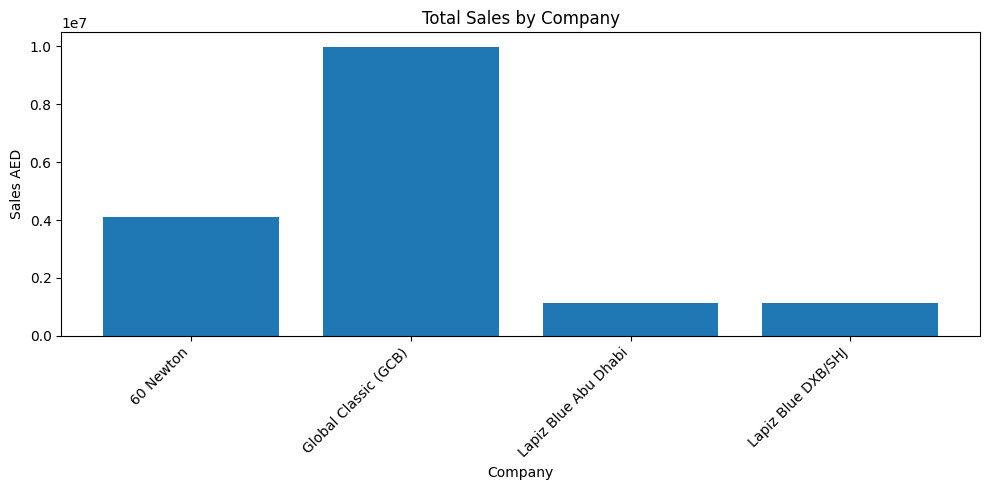

In [ ]:
#sales cahrt basic

sales_by_company = real_sales_lines.groupby("entity_name").agg(
    sales_aed=("line_subtotal", "sum")
).reset_index()

plt.figure(figsize=(10, 5))
plt.bar(sales_by_company["entity_name"], sales_by_company["sales_aed"])
plt.title("Total Sales by Company")
plt.xlabel("Company")
plt.ylabel("Sales AED")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

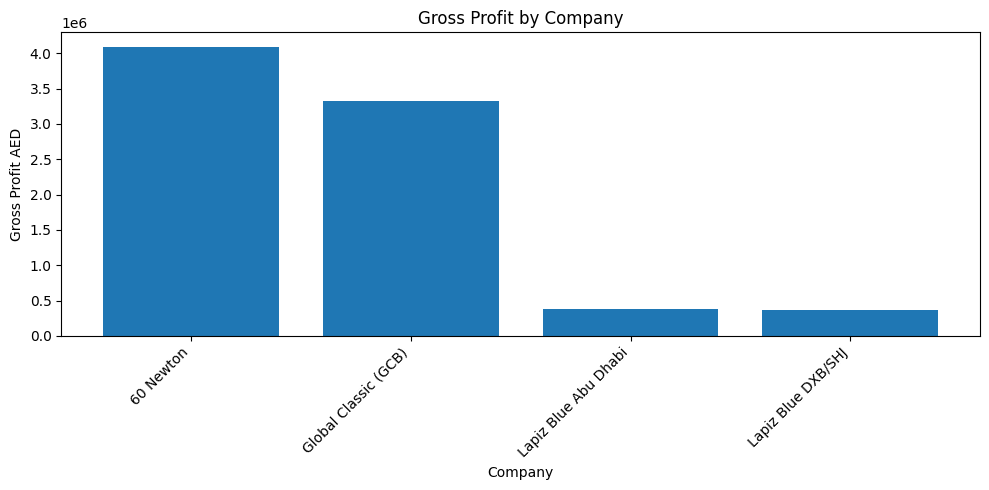

In [ ]:
# gross profit by company
gp_by_company = real_sales_lines.groupby("entity_name").agg(
    gross_profit_aed=("gross_profit", "sum")
).reset_index()

plt.figure(figsize=(10, 5))
plt.bar(gp_by_company["entity_name"], gp_by_company["gross_profit_aed"])
plt.title("Gross Profit by Company")
plt.xlabel("Company")
plt.ylabel("Gross Profit AED")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

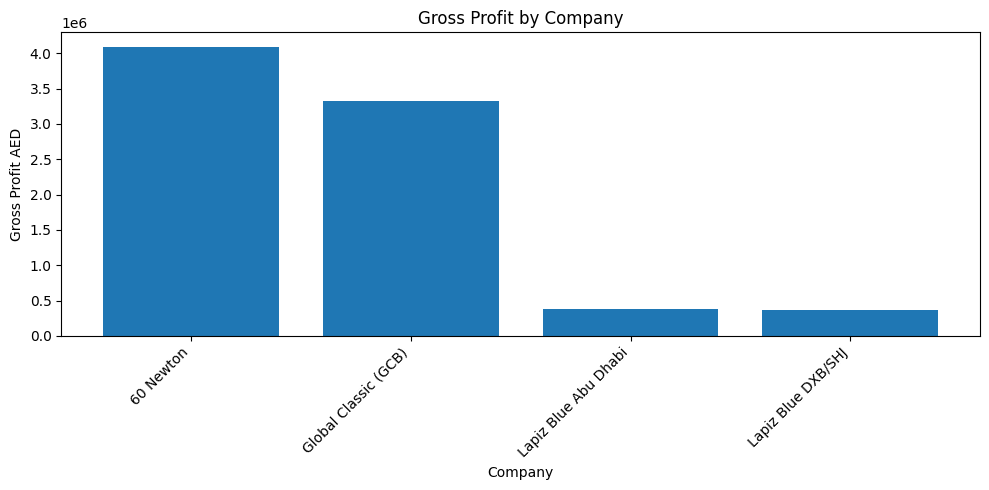

In [ ]:
#anamoly dist
gp_by_company = real_sales_lines.groupby("entity_name").agg(
    gross_profit_aed=("gross_profit", "sum")
).reset_index()

plt.figure(figsize=(10, 5))
plt.bar(gp_by_company["entity_name"], gp_by_company["gross_profit_aed"])
plt.title("Gross Profit by Company")
plt.xlabel("Company")
plt.ylabel("Gross Profit AED")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
files.download("person4_duplicate_customer_dataset.csv")
files.download("person5_anomaly_detection_dataset.csv")
files.download("dashboard_monthly_sales_summary.csv")
files.download("dashboard_monthly_collections_summary.csv")
files.download("dashboard_payables_summary.csv")
files.download("dashboard_inventory_dataset.csv")
files.download("dashboard_pnl_summary.csv")
files.download("dashboard_targets_dataset.csv")
files.download("lapiz_dashboard_clean_outputs.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>